In [46]:
import pandas as pd
import numpy as np

In [47]:
# Dataset
# Read in the data
df = pd.read_csv('../dataset/tweet_data/tweet_data.csv')

In [48]:
df.sample(10)

,textID,tweet_text,sentiment
1672,1958066158,Really Wish i could see dave from @reemerband ...,negative
591,1957246312,My throat hurts and I can't sleep.,negative
11564,1694903423,i can be a good girl at school.. today i was!!...,positive
5244,1963105212,my baby's off on his adventure. 14.5 hours in ...,negative
18049,1753665866,It's sunny and I feel really well today! Yipp...,positive
1246,1957588348,@solobasssteve I'm with you there - filing is ...,positive
11792,1695026952,check out this funny movie http://tinyurl.com...,positive
5100,1963000451,gonna do laundry....never did laundry @ a hote...,negative
11199,1694706124,Happy Star Wars Day!!! May The 4th Be With You!,positive
15706,1752675281,@TravellingSales WELCOME BACK see you tomorro...,positive


## Visualise data

In [49]:
import matplotlib.pyplot as plt

           textID  tweet_text
sentiment                    
negative     8830        8830
positive     9897        9897


<BarContainer object of 2 artists>

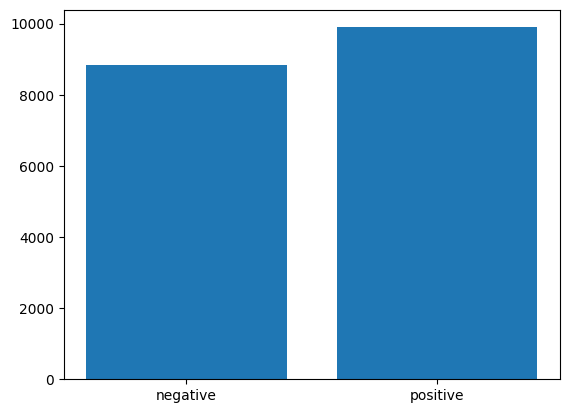

In [50]:
sentiment_count = df.groupby('sentiment').count()
# show number of count of positive and negative
print(sentiment_count)
# Showing the bar plot of positive and negative
plt.bar(sentiment_count.index.values, sentiment_count['tweet_text'])

# Using module to show most used words for pos and neg tweets

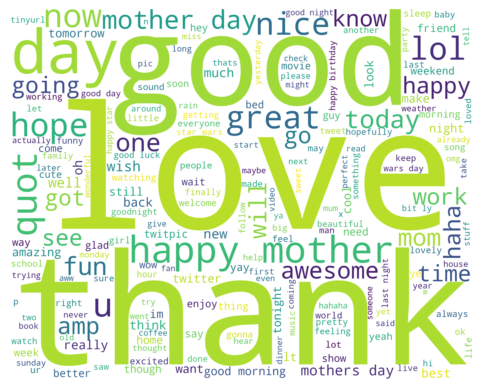

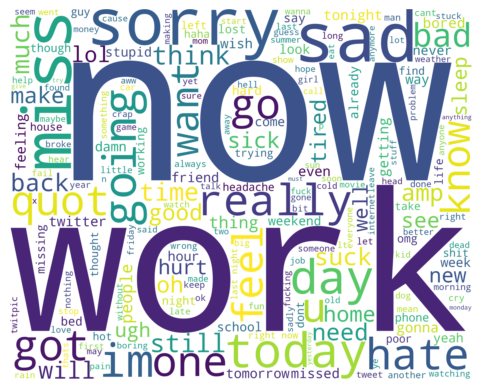

In [51]:
from wordcloud import WordCloud

positive_tweets = df[df['sentiment'] == 'positive']
negative_tweets = df[df['sentiment'] == 'negative']

txt_positive = " ".join(tweet.lower() for tweet in positive_tweets['tweet_text'])
txt_negative = " ".join(tweet.lower() for tweet in negative_tweets['tweet_text'])

# Generate a word cloud image
wordcloud_positive = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_positive)
wordcloud_negative = WordCloud(stopwords=None, background_color='white', width=2500, height=2000).generate(txt_negative)

# Display the generated image:
plt.imshow(wordcloud_positive, interpolation='bilinear')
plt.axis("off")
plt.show()

plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis("off")
plt.show()



# Text Normalization

In [52]:
import re

In [53]:
# example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"

In [54]:
# Remove emojis
import emoji

In [55]:

def convert_emoji_to_text(text):
    text = emoji.demojize(text) # Converting the emoji to their word meaning
    text = text.replace(":"," ") # Replacing the colon symbol with a space
    return text

#print(convert_emoji_to_text(example))


In [56]:
# Remove links
def remove_links(text, replace_with=""):
    text = re.sub('(http|https):\/\/\S+', replace_with, text) # regex to remove any links starting with http or https
    return text
#print (remove_links(example))

In [57]:
# Remove hashtags
def remove_hashtags(text, replace_with=""):
    text = re.sub('#+', replace_with, text) # regex to remove any hashtags
    return text

#print (remove_hashtags(example))

In [58]:
# General cleaning / text normalization

In [59]:
# Making string all lowercase
def lower_case_string(text):
    return text.lower()

#print (lower_case_string(example))

In [60]:
# Removing repeated characters
def remove_letter_repetitions(text):
    return re.sub(r'(.)\1+', r'\1\1', text) # regex to remove repeated chars, firstly matches a char which is repeated more than once, then replaces it with the same char twice

#print (remove_letter_repetitions(example))

# Removing punctuation repetitions
def remove_punctuation_repetitions(text, replace_with=""):
    return re.sub(r'[\?\.\!]+(?=[\?\.\!])', replace_with, text) # regex to remove repeated punctuation, firstly matches a punctuation which is repeated more than once, then replaces it with a single punctuation

#print (remove_punctuation_repetitions(example))

In [61]:
# Working with contractions
# Using a contraction dictionary we can replace contractions with their full form
import contractions

In [62]:
# Replacing contractions with their full form: e.g I'm -> I am
def replace_contractions(text):
    text = contractions.fix(text) # Using built in method from contractions library
    return text

#print(replace_contractions(example))

# Tokenization
- stop words
- punctionation
- numbers

In [63]:
# Using nltk library
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [64]:
def tokenize(text):
    tokens = word_tokenize(text)
    return tokens

#print(tokenize(example))

In [65]:
# Using a more complex and complete tokenizer
import string
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/thomashazekamp/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [66]:
stop_words = set(stopwords.words('english')) # Getting the stop words from nltk
print(stop_words)

{'didn', 'those', "needn't", 'an', 've', 'all', 'any', "isn't", 'or', 'only', 'wasn', 'have', 'what', 'into', 'wouldn', "wouldn't", "doesn't", 'couldn', 'nor', 'they', 'do', 'was', 'had', 'a', 'for', 'can', 'in', 'whom', 'to', 'under', 'shan', 'doesn', 'ain', 'very', 'against', "you'd", 'each', 'am', "you'll", 'our', 'than', 'needn', 'ourselves', 'few', 'such', 'this', 'because', 'is', "should've", 'yourself', 'has', 'other', 'from', 'm', 'theirs', 'during', 'isn', 'then', 'through', "won't", 'won', 'between', 'itself', 'having', 'until', 'where', "aren't", 'll', 'ours', 'after', 'below', 'yourselves', "mustn't", 'now', 'hasn', 'i', 'my', 'weren', 'it', 'how', 'of', 'hers', 'on', 'about', 'haven', 'we', 'just', 'out', 'over', 'so', 'if', "hasn't", 'off', 'both', "weren't", 'when', 'that', 'too', 'yours', 'are', 'and', 'most', 'but', 'were', 'with', "mightn't", "shouldn't", 'their', 'while', 'down', 'further', 'being', 'more', "wasn't", 'doing', 'own', "that'll", 'will', 'been', 'you', 

In [67]:

# Depending if we want to keep punctuation, alphanumeric characters and stopwords we can use the following function with True or False
def custom_tokenization(text, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False):
    token_list = word_tokenize(text)

    punctuation_chars = "!\"#$%&'()*+, -./:;<=>?@[\]^_`{|}~"

    if not keep_punctuation:
        token_list = [token for token in token_list if token not in punctuation_chars] # Add only if not in the punctuation list
    if not keep_alphanum:
        token_list = [token for token in token_list if token.isalpha()] # Add only if is a letter
    if not keep_stopwords:
        stop_words = set(stopwords.words('english'))
        stop_words.discard('not') # Remove stop words which are relevant for sentiment analysis from the stop words list !NOTE: Can add more words to be excluded
        token_list = [token for token in token_list if token not in stop_words] # Add only if not in the stop words list

    return token_list

#print(custom_tokenization(example, keep_punctuation = False, keep_alphanum = False, keep_stopwords = False))

## Stemming

In [68]:
from nltk.stem import PorterStemmer 
from nltk.stem import LancasterStemmer # more agressive stemming
from nltk.stem import SnowballStemmer # better than porter and newer
#NOTE: can look at more stemming algos

In [69]:
porter_stemmer = PorterStemmer()
lancaster_stemmer = LancasterStemmer()
snowball_stemmer = SnowballStemmer('english')


In [70]:
# Function to stem tokens given a stemming algorithm
def stemming_tokens(tokens, stemmer):
    token_list = [stemmer.stem(token) for token in tokens] # Add the new stemmed token to the list
    return token_list

In [71]:
#print(stemming_tokens(tokenize(example), snowball_stemmer))

# Preprocessing text

In [72]:
# Processing the string/text

def process_text(text):
    # Removing links and converting emojis to text
    p_txt = remove_links(text)
    p_txt = convert_emoji_to_text(p_txt)

    # Removing hashtags, making string lowercase, removing repeated characters and punctuation and replacing contractions
    p_txt = remove_hashtags(p_txt)
    p_txt = lower_case_string(p_txt)
    p_txt = remove_letter_repetitions(p_txt)
    p_txt = remove_punctuation_repetitions(p_txt)
    p_txt = replace_contractions(p_txt)
    
    # Tokenizing the string
    #p_txt = tokenize(p_txt)
    p_txt = custom_tokenization(p_txt)

    # Stemming the tokens
    p_txt = stemming_tokens(p_txt, snowball_stemmer)
    return p_txt

example = "Tom loved this fooooooood spot. This is their website for more info: https://www.examplefoodspot.com. I'm sure we'll go here again. 😊 #food #greatfood #BESTFOOD!!!!!!"
print(process_text(example))

['tom', 'love', 'food', 'spot', 'websit', 'info', 'sure', 'go', 'food', 'greatfood', 'bestfood']


# Text Vectorization

In [74]:
df["tokens"] = df["tweet_text"].apply(process_text)
df["tweet_sentiment"] = df["sentiment"].apply(lambda x: 1 if x == "positive" else 0)

df.head(10)

,textID,tweet_text,sentiment,tokens,tween_sentiment,tweet_sentiment
0,1956967666,Layin n bed with a headache ughhhh...waitin o...,negative,"[layin, n, bed, headach, call]",0,0
1,1956967696,Funeral ceremony...gloomy friday...,negative,"[funer, friday]",0,0
2,1956967789,wants to hang out with friends SOON!,positive,"[want, hang, friend, soon]",1,1
3,1956968477,Re-pinging @ghostridah14: why didn't you go to...,negative,"[not, go, prom, bf, not, like, friend]",0,0
4,1956968636,Hmmm. http://www.djhero.com/ is down,negative,[hmm],0,0
5,1956969035,@charviray Charlene my love. I miss you,negative,"[charviray, charlen, love, miss]",0,0
6,1956969172,@kelcouch I'm sorry at least it's Friday?,negative,"[kelcouch, sorri, least, friday]",0,0
7,1956969531,Choked on her retainers,negative,"[choke, retain]",0,0
8,1956970047,Ugh! I have to beat this stupid song to get to...,negative,"[ugh, beat, stupid, song, get, next, rude]",0,0
9,1956970424,@BrodyJenner if u watch the hills in london u ...,negative,"[brodyjenn, watch, hill, london, realis, tourt...",0,0


In [75]:
x  = df["tokens"].tolist()
y = df["tweet_sentiment"].tolist()

## Bag of words

In [76]:
corpus = [["love", "nlp"],
          ["miss", "you"],
          ["hate", "hate", "hate", "love"],
          ["happy", "love", "hate",],
          ["i", "lost", "my", "computer"],
          ["i", "am", "so", "sad"]]

In [78]:
from sklearn.feature_extraction.text import CountVectorizer # Bag of words

def fit_cv(tweet_corpus):
    cv_vect = CountVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x) # Using custom tokenizer and preprocessor

    cv_vect.fit(tweet_corpus)

    return cv_vect

cv_vect = fit_cv(corpus)

ft = cv_vect.get_feature_names_out()

print(ft)

['am' 'computer' 'happy' 'hate' 'i' 'lost' 'love' 'miss' 'my' 'nlp' 'sad'
 'so' 'you']


In [79]:
cv_mtx = cv_vect.transform(corpus)

In [80]:
cv_mtx.toarray()

array([[0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1],
       [0, 0, 0, 3, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0],
       [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0]])

## TD-IDF

- term frequency

In [81]:
corpus = [["love", "nlp"],
          ["miss", "you"],
          ["hate", "hate", "hate", "love"],
          ["happy", "love", "hate",],
          ["i", "lost", "my", "computer"],
          ["i", "am", "so", "sad"]]

In [82]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [83]:
def fit_tfidf(tween_corpus):
    tf_vect = TfidfVectorizer(preprocessor=lambda x: x, tokenizer=lambda x: x) # Using custom tokenizer and preprocessor

    tf_vect.fit(tween_corpus)
    return tf_vect

In [84]:
tf_vect = fit_tfidf(corpus)
tf_mtx = tf_vect.transform(corpus)

tf_mtx.toarray()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.56921261, 0.        , 0.        , 0.82219037,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.70710678, 0.        , 0.        ,
        0.        , 0.        , 0.70710678],
       [0.        , 0.        , 0.        , 0.96260755, 0.        ,
        0.        , 0.27089981, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.68172171, 0.55902156, 0.        ,
        0.        , 0.47196441, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.52182349, 0.        , 0.        , 0.42790272,
        0.52182349, 0.        , 0.        , 0.52182349, 0.        ,
        0.        , 0.        , 0.        ],
       [0.52182349, 0.        , 0.        , 0.        , 0.42790272,
        0.        , 0.     